## What is the most optimal skill to learn for Data Analyst

### Methodology

1. Group skills to determine median salary and likelihood of being in posting
2. Visualize median salary vs percent skill demand
3. (Optional) Determine if certain technologies are more prevalent

### Original Exploration

[15_Matplotlib_Scatter_Plots.ipynb](2_Advanced\15_Matplotlib_Scatter_Plot.ipynb)

[16_Matplotlib_Advanced_Customization.ipynb](2_Advanced\16_Matplotlib_Advanced_Customization.ipynb)

### Import Libraries and Data

In [11]:
# Importing Libraries
import ast
import pandas as pd
import seaborn as sns
from datasets import load_dataset
import matplotlib.pyplot as plt  

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [12]:
df_DA_IN = df[(df['job_title_short'] == 'Data Analyst') & (df['job_country'] == 'India')].copy()

In [13]:
USD_TO_INR = 82

df_DA_IN['salary_year_avg_inr'] = df_DA_IN['salary_year_avg'] * USD_TO_INR

df_DA_IN

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills,salary_year_avg_inr
38,Data Analyst,Data Quality and Governance Analyst 1,India,via Trabajo.org,Full-time,False,India,2023-07-23 13:24:57,False,False,India,None,NaN,NaN,"Jones Lang LaSalle IP, Inc","[sql, python, databricks, power bi, excel, wor...","{'analyst_tools': ['power bi', 'excel', 'word'...",NaN
123,Data Analyst,Data Analytics work from home job/internship a...,Anywhere,via LinkedIn,Part-time,True,India,2023-03-07 13:37:56,False,False,India,None,NaN,NaN,Inoket Solutions Private Limited,"[sql, excel, word, powerpoint, outlook, power bi]","{'analyst_tools': ['excel', 'word', 'powerpoin...",NaN
159,Data Analyst,Data Analyst,"Hyderabad, Telangana, India",via LinkedIn,Contractor,False,India,2023-11-28 13:12:07,False,False,India,None,NaN,NaN,Fusion Plus Solutions Inc,[sql],{'programming': ['sql']},NaN
171,Data Analyst,Data Base work from home job/internship at Mga...,Anywhere,via LinkedIn,Full-time,True,India,2023-01-14 13:11:58,False,False,India,None,NaN,NaN,Mgadz Inc,"[sas, sas, sql]","{'analyst_tools': ['sas'], 'programming': ['sa...",NaN
194,Data Analyst,Data Analyst,India,via BeBee India,Full-time,False,India,2023-06-20 13:11:10,False,False,India,None,NaN,NaN,QuEST Global Services Pte. Ltd,"[python, sql, excel, ms access, powerpoint]","{'analyst_tools': ['excel', 'ms access', 'powe...",NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
785517,Data Analyst,Analyst - Data Analytics/SQL (2-9 yrs),"Gurugram, Haryana, India",via BeBee India,Full-time,False,India,2023-10-16 06:10:56,False,False,India,None,NaN,NaN,iimjobs,[power bi],{'analyst_tools': ['power bi']},NaN
785548,Data Analyst,Data Analyst,"Bengaluru, Karnataka, India",via LinkedIn,Full-time,False,India,2023-01-19 06:14:17,False,False,India,None,NaN,NaN,Artech L.L.C.,"[sql, excel]","{'analyst_tools': ['excel'], 'programming': ['...",NaN
785628,Data Analyst,Data Analyst,"Gurugram, Haryana, India",via LinkedIn,Full-time,False,India,2023-01-09 06:08:12,False,False,India,None,NaN,NaN,GUS Global Services India Pvt. Ltd.,"[r, python, sql, sap, power bi, tableau, excel]","{'analyst_tools': ['sap', 'power bi', 'tableau...",NaN
785691,Data Analyst,Business Intelligence Engineer,"Chennai, Tamil Nadu, India",via LinkedIn,Full-time,False,India,2023-01-23 06:12:09,False,False,India,None,NaN,NaN,Mobile Programming LLC,"[sql, python, shell, sql server, tableau, micr...","{'analyst_tools': ['tableau', 'microstrategy']...",NaN


In [14]:
df_DA_IN = df_DA_IN.dropna(subset=['salary_year_avg_inr'])

df_DA_IN_exploded = df_DA_IN.explode('job_skills')

df_DA_IN_exploded[['salary_year_avg_inr', 'job_skills']].head(5)

,salary_year_avg_inr,job_skills
11412,4132800.0,python
11412,4132800.0,sql
11412,4132800.0,aws
11412,4132800.0,azure
11412,4132800.0,excel


In [15]:
df_DA_skills = df_DA_IN_exploded.groupby('job_skills')['salary_year_avg_inr'].agg(['count', 'median']).sort_values(by='count', ascending=False)

df_DA_skills = df_DA_skills.rename(columns={'count': 'skill_count', 'median': 'median_salary'})

DA_job_count = len(df_DA_IN)

df_DA_skills['skill_percent'] = df_DA_skills['skill_count'] / DA_job_count * 100

skill_percent = 10

df_DA_skills_high_demand = df_DA_skills[df_DA_skills['skill_percent'] > skill_percent]

df_DA_skills_high_demand

,skill_count,median_salary,skill_percent
job_skills,,,
sql,46,7876100.0,48.936170
excel,39,8077000.0,41.489362
python,36,7876100.0,38.297872
tableau,20,8863175.0,21.276596
r,18,6494400.0,19.148936
power bi,17,9116350.0,18.085106
azure,15,7675200.0,15.957447
aws,12,6494400.0,12.765957
oracle,11,6494400.0,11.702128


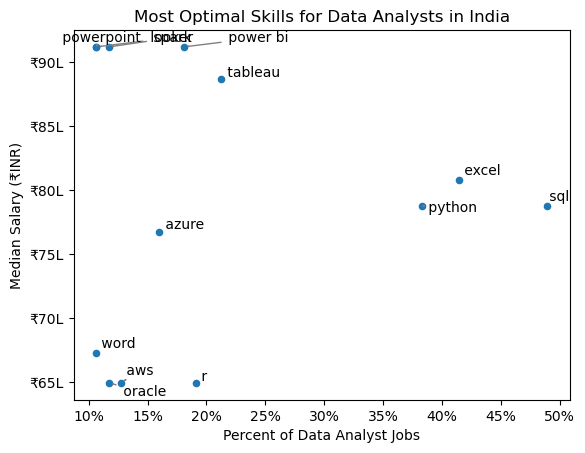

In [16]:
from adjustText import adjust_text

df_DA_skills_high_demand.plot(kind='scatter', x='skill_percent', y='median_salary')

# Prepare text for adjustText
texts = []
for i, txt in enumerate(df_DA_skills_high_demand.index):
    texts.append(plt.text(df_DA_skills_high_demand['skill_percent'].iloc[i], df_DA_skills_high_demand['median_salary'].iloc[i], " " + txt))

# Adjust text to avoid overlap and add arrows
adjust_text(texts, arrowprops=dict(arrowstyle='->', color='gray'))

#Set axis labels, title, and legend
plt.xlabel('Percent of Data Analyst Jobs')
plt.ylabel('Median Salary (₹INR)')  # Assuming this is the label you want for y-axis
plt.title('Most Optimal Skills for Data Analysts in India')

from matplotlib.ticker import PercentFormatter

# Get current axes, set limits, and format axes
ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos: f'₹{int(y/100000)}L'))  # Example formatting y-axis
ax.xaxis.set_major_formatter(PercentFormatter(decimals=0))

plt.show()

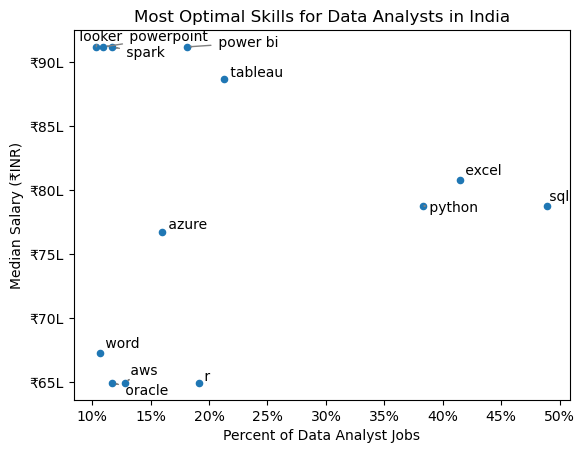

In [17]:
from adjustText import adjust_text
import numpy as np

# ✅ Create a copy so original data stays unchanged
df_plot1 = df_DA_skills_high_demand.copy()

# ✅ Create offset columns (float to avoid warnings)
df_plot1['x_offset'] = 0.0
df_plot1['y_offset'] = 0.0

# ✅ Group overlapping points (same % and same salary)
grouped = df_plot1.groupby(['skill_percent', 'median_salary'])

# ✅ Apply symmetric offsets ONLY where needed
for _, group in grouped:
    n = len(group)
    
    if n > 1:
        offsets = np.linspace(-0.3, 0.3, n)
        
        for i, idx in enumerate(group.index):
            df_plot1.loc[idx, 'x_offset'] = offsets[i]
            df_plot1.loc[idx, 'y_offset'] = offsets[i] * 500  # small INR shift

# ✅ NEW: Create plotting columns (THIS FIXES YOUR ERROR)
df_plot1['plot_x'] = df_plot1['skill_percent'] + df_plot1['x_offset']
df_plot1['plot_y'] = df_plot1['median_salary'] + df_plot1['y_offset']

# ✅ Plot using correct column names
df_plot1.plot(
    kind='scatter',
    x='plot_x',
    y='plot_y'
)

# ✅ Add labels
texts = []
for i, txt in enumerate(df_plot1.index):
    texts.append(
        plt.text(
            df_plot1['plot_x'].iloc[i],   # ✅ use new columns
            df_plot1['plot_y'].iloc[i],   # ✅ use new columns
            " " + txt
        )
    )

# ✅ Adjust text to avoid overlap
adjust_text(texts, arrowprops=dict(arrowstyle='->', color='gray'))

# ✅ Labels & title
plt.xlabel('Percent of Data Analyst Jobs')
plt.ylabel('Median Salary (₹INR)')
plt.title('Most Optimal Skills for Data Analysts in India')

from matplotlib.ticker import PercentFormatter

# ✅ Format axes
ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos: f'₹{int(y/100000)}L'))
ax.xaxis.set_major_formatter(PercentFormatter(decimals=0))

plt.show()

In [18]:
df_technology = df['job_type_skills'].copy()

# remove duplicates
df_technology = df_technology.drop_duplicates()

# remove NaN values
df_technology = df_technology.dropna()

# combine all dictionaries into one
technology_dict = {}
for row in df_technology:
    row_dict = ast.literal_eval(row)  # convert string to dictionary
    for key, value in row_dict.items():
        if key in technology_dict:  # if key already exists in technology_dict, add value to existing value
            technology_dict[key] += value
        else:                       # if key does not exist in technology_dict, add key and value
            technology_dict[key] = value

# remove duplicates by converting values to set then back to list
for key, value in technology_dict.items():
    technology_dict[key] = list(set(value))

technology_dict

{'analyst_tools': ['microstrategy',
  'ssis',
  'ms access',
  'datarobot',
  'outlook',
  'sas',
  'powerbi',
  'splunk',
  'nuix',
  'sharepoint',
  'ssrs',
  'sheets',
  'powerpoint',
  'word',
  'spss',
  'alteryx',
  'cognos',
  'esquisse',
  'dax',
  'qlik',
  'spreadsheet',
  'looker',
  'power bi',
  'visio',
  'msaccess',
  'excel',
  'sap',
  'tableau'],
 'programming': ['erlang',
  't-sql',
  'sass',
  'sas',
  'assembly',
  'sql',
  'solidity',
  'groovy',
  'pascal',
  'swift',
  'julia',
  'fortran',
  'delphi',
  'vb.net',
  'clojure',
  'c++',
  'c#',
  'css',
  'no-sql',
  'lisp',
  'objective-c',
  'mongodb',
  'nosql',
  'scala',
  'go',
  'ocaml',
  'lua',
  'html',
  'dart',
  'r',
  'php',
  'vba',
  'perl',
  'typescript',
  'ruby',
  'cobol',
  'visual basic',
  'rust',
  'elixir',
  'java',
  'golang',
  'f#',
  'apl',
  'python',
  'crystal',
  'visualbasic',
  'c',
  'javascript',
  'haskell',
  'matlab',
  'powershell',
  'shell',
  'mongo',
  'kotlin',
  'b

In [19]:
df_technology = pd.DataFrame(list(technology_dict.items()), columns=['technology', 'skills'])

df_technology = df_technology.explode('skills')

df_technology

,technology,skills
0,analyst_tools,microstrategy
0,analyst_tools,ssis
0,analyst_tools,ms access
0,analyst_tools,datarobot
0,analyst_tools,outlook
...,...,...
9,sync,twilio
9,sync,microsoft teams
9,sync,rocketchat
9,sync,ringcentral


In [20]:
df_plot = df_plot1.merge(df_technology, left_on='job_skills', right_on='skills')

df_plot

,skill_count,median_salary,skill_percent,x_offset,y_offset,plot_x,plot_y,technology,skills
0,46,7876100.0,48.936170,0.0,0.0,48.936170,7876100.0,programming,sql
1,39,8077000.0,41.489362,0.0,0.0,41.489362,8077000.0,analyst_tools,excel
2,36,7876100.0,38.297872,0.0,0.0,38.297872,7876100.0,programming,python
3,20,8863175.0,21.276596,0.0,0.0,21.276596,8863175.0,analyst_tools,tableau
4,18,6494400.0,19.148936,0.0,0.0,19.148936,6494400.0,programming,r
5,17,9116350.0,18.085106,0.0,0.0,18.085106,9116350.0,analyst_tools,power bi
6,15,7675200.0,15.957447,0.0,0.0,15.957447,7675200.0,cloud,azure
7,12,6494400.0,12.765957,0.0,0.0,12.765957,6494400.0,cloud,aws
8,11,6494400.0,11.702128,0.0,0.0,11.702128,6494400.0,cloud,oracle
9,11,9116350.0,11.702128,0.0,0.0,11.702128,9116350.0,libraries,spark


In [21]:
# Create a copy for plotting
df_plot = df_plot.copy()

# Step 1: Identify overlapping points
duplicates = df_plot.duplicated(subset=['skill_percent', 'median_salary'], keep=False)

# Step 2: Create offset columns
df_plot['x_offset'] = 0.0
df_plot['y_offset'] = 0.0

# Group duplicates
grouped = df_plot.groupby(['skill_percent', 'median_salary'])

for _, group in grouped:
    n = len(group)
    
    if n > 1:
        offsets = np.linspace(-0.3, 0.3, n)  # evenly spread
        
        for i, idx in enumerate(group.index):
            df_plot.loc[idx, 'x_offset'] = offsets[i]
            df_plot.loc[idx, 'y_offset'] = offsets[i] * 500

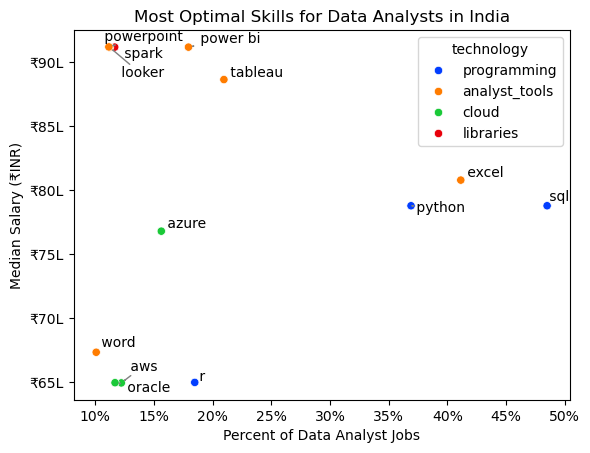

In [32]:
from adjustText import adjust_text
import numpy as np

df_plot['skill_percent'] = df_plot['skill_percent'] + np.random.uniform(-0.3, 0.3, len(df_plot))
df_plot['median_salary'] = df_plot['median_salary'] + np.random.uniform(-500, 500, len(df_plot))

# df_plot.plot(kind='scatter', x='skill_percent_jitter', y='median_salary_jitter')
sns.scatterplot(
    data=df_plot,
    x='skill_percent',
    y='median_salary',
    hue='technology',
    palette='bright',
    legend='full'
)

# Prepare text for adjustText
texts = []
for i in range(len(df_plot)):
    texts.append(
        plt.text(
            df_plot['skill_percent'].iloc[i],
            df_plot['median_salary'].iloc[i],
            " " + df_plot['skills'].iloc[i]   
        )
    )

# Adjust text to avoid overlap and add arrows
adjust_text(texts, arrowprops=dict(arrowstyle='->', color='gray'))

# Set axis labels and title
plt.xlabel('Percent of Data Analyst Jobs')
plt.ylabel('Median Salary (₹INR)')
plt.title('Most Optimal Skills for Data Analysts in India')

from matplotlib.ticker import PercentFormatter

# Format axes
ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos: f'₹{int(y/100000)}L'))
ax.xaxis.set_major_formatter(PercentFormatter(decimals=0))

plt.show()